In [ ]:
from google.colab import files
uploaded = files.upload()


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

**Load Dataset**

In [ ]:
df = pd.read_csv("customer_data_200_rows.csv")

df.head()

,Age,Gender,PastPurchases,ClickedAd
0,58,Male,0,0
1,33,Male,4,0
2,52,Male,18,0
3,19,Male,6,0
4,56,Male,17,1


**Check Dataset**

In [ ]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Age            200 non-null    int64 
 1   Gender         200 non-null    object
 2   PastPurchases  200 non-null    int64 
 3   ClickedAd      200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


,0
Age,0
Gender,0
PastPurchases,0
ClickedAd,0


**Encode Gender**

In [ ]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

df.head()

,Age,Gender,PastPurchases,ClickedAd
0,58,1,0,0
1,33,1,4,0
2,52,1,18,0
3,19,1,6,0
4,56,1,17,1


**Features & Target**

In [ ]:
X = df.drop("ClickedAd", axis=1)

y = df["ClickedAd"]

**Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Train Logistic Regression**

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

**Make Predictions**

In [ ]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 0, 0, 0, 0, 1, 0, 1, 0, 0])

**Evaluate Model**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.675
Precision: 0.6363636363636364
Recall   : 0.4375
F1 Score : 0.5185185185185185


**Confusion Matrix**

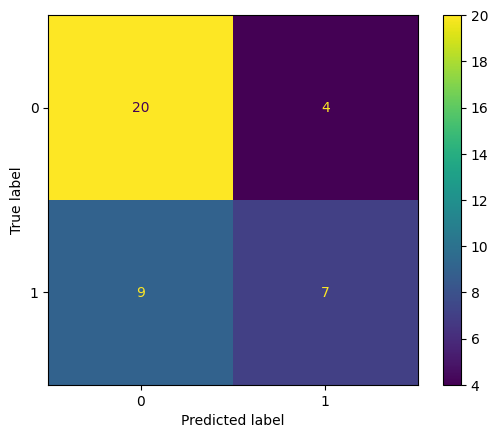

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()